## Exercício prático — Dia 02
Complete os passos no notebook usando a base `base_rh.xlsx` e crie os gráficos finais pedindo ao gerente de produção.

1. Carregue `base_rh.xlsx` com `pd.read_excel(URL)` e converta `Data_Admissao` para datetime. Crie `Ano_Admissao` com `.dt.year`.
2. Use `groupby(["Departamento", "Cargo"])` para contar funcionários e exiba o resultado.
3. Use `groupby("Ano_Admissao")` para contar admissões por ano e filtre 2020–2024 com `query()`.
4. Crie uma tabela de metas de headcount por departamento com `pd.DataFrame` e faça `merge left` com o total por departamento. Identifique se a meta foi atingida.
5. Crie um `pivot_table` de `Salario` médio por `Departamento` e `Genero`. Calcule a diferença `F - M`.
6. Plote admissões por ano com `plt.plot(..., marker="o")`.
7. Plote o `pivot_table` de salário médio por gênero com `pivot.plot(kind="bar")`.
8. Faça commit com mensagem `semana 05 - dia 02: groupby, merge, pivot_table, graficos`.


In [1]:
#1. ----------------------------------------------------------------------------------------------------------------------------
#carregar base de dados:
import pandas as pd
import matplotlib.pyplot as plt

URL = ("https://raw.githubusercontent.com/"
"cfneves/turma-visualizacao-de-dados/"
"master/aulas/semana_04/bases/base_rh.xlsx"
)
df = pd.read_excel(URL)

#onversão de string para datetime:
df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"
)

print(f"Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")
print(df.dtypes)

#checklist:
#print(df.head())
#print(df.info())
#print(df.describe())
#print(df.isnull().sum())
#print(df.value_counts())
#print(nunique))

#criar coluna "Ano_admissao" com ".dt.year"
df["Ano_admissao"] = df["Data_Admissao"].dt.year
print(df.head())

Dataset: 1000 linhas e 10 colunas
ID_Funcionario             int64
Nome                         str
Departamento                 str
Cargo                        str
Salario                  float64
Data_Admissao     datetime64[us]
Genero                       str
Idade                      int64
Estado_Civil                 str
Status                       str
dtype: object
   ID_Funcionario                 Nome Departamento        Cargo   Salario  \
0               1          Julia Nunes    Logística  Coordenador   9088.34   
1               2   Sr. Gustavo Duarte           TI      Gerente   8155.98   
2               3  Srta. Mariana Cunha           RH  Coordenador  14027.93   
3               4   Ana Sophia da Cruz     Produção      Técnico   6647.97   
4               5    Dr. Nicolas Pinto     Produção      Gerente   8730.19   

  Data_Admissao Genero  Idade Estado_Civil   Status  Ano_admissao  
0    2024-08-13      F     43     Solteiro  Inativo          2024  
1    2017-04-29  

In [2]:
#2. ----------------------------------------------------------------------------------------------------------------------------
#agrupar "Departamento" e "Cargo" para contabilizar o número de funcionários:
df.groupby(["Departamento", "Cargo"]).size()
print(df.groupby(["Departamento", "Cargo"]).size())

Departamento  Cargo      
Financeiro    Analista       40
              Assistente     30
              Coordenador    37
              Gerente        44
              Técnico        38
Logística     Analista       29
              Assistente     38
              Coordenador    38
              Gerente        33
              Técnico        18
Produção      Analista       22
              Assistente     41
              Coordenador    40
              Gerente        43
              Técnico        36
RH            Analista       32
              Assistente     35
              Coordenador    44
              Gerente        30
              Técnico        25
TI            Analista       31
              Assistente     25
              Coordenador    28
              Gerente        31
              Técnico        32
Vendas        Analista       24
              Assistente     30
              Coordenador    38
              Gerente        40
              Técnico        28
dtype: int64


In [3]:
#3. ----------------------------------------------------------------------------------------------------------------------------
#agrupar "Ano_Admissao" para contabilizar as admissões por ano e filtrar 2020–2024 com `query()`:
admissoes_por_ano = df.groupby("Ano_admissao").size().reset_index(name="Contagem")
admissoes_filtradas = admissoes_por_ano.query("Ano_admissao >= 2020 and Ano_admissao <= 2024")
print(admissoes_filtradas)

   Ano_admissao  Contagem
5          2020        94
6          2021        94
7          2022       108
8          2023       106
9          2024       113


In [4]:
#4. ----------------------------------------------------------------------------------------------------------------------------
#Criar uma tabela de metas de headcount por departamento com `pd.DataFrame` e fazer `merge left` com o total por departamento. Identificar se a meta foi atingida:
metas = pd.DataFrame({
    "Departamento": ["Vendas", "Marketing", "TI", "Recursos Humanos"],
    "Meta_Headcount": [50, 30, 40, 25]
})
total_por_departamento = df.groupby("Departamento").size().reset_index(name="Total_Funcionários")
resultado = pd.merge(metas, total_por_departamento, on="Departamento", how="left")
resultado["Meta_Atingida"] = resultado["Total_Funcionários"] >= resultado["Meta_Headcount"]
print(resultado)

       Departamento  Meta_Headcount  Total_Funcionários  Meta_Atingida
0            Vendas              50               160.0           True
1         Marketing              30                 NaN          False
2                TI              40               147.0           True
3  Recursos Humanos              25                 NaN          False


In [5]:
#5. ----------------------------------------------------------------------------------------------------------------------------
#Criar um `pivot_table` de `Salario` médio por `Departamento` e `Genero`. Calcular a diferença `F - M`:
pivot = df.pivot_table(values="Salario", index="Departamento", columns="Genero", aggfunc="mean")
pivot["Diferença_F_M"] = pivot["F"] - pivot["M"]
print(pivot)

Genero                  F            M  Diferença_F_M
Departamento                                         
Financeiro    8467.258571  8208.561939     258.696633
Logística     8843.485258  8944.411864    -100.926607
Produção      8797.639529  9118.663711    -321.024182
RH            9009.201250  8546.056410     463.144840
TI            8107.010139  8177.382267     -70.372128
Vendas        8926.643896  7751.590120    1175.053776


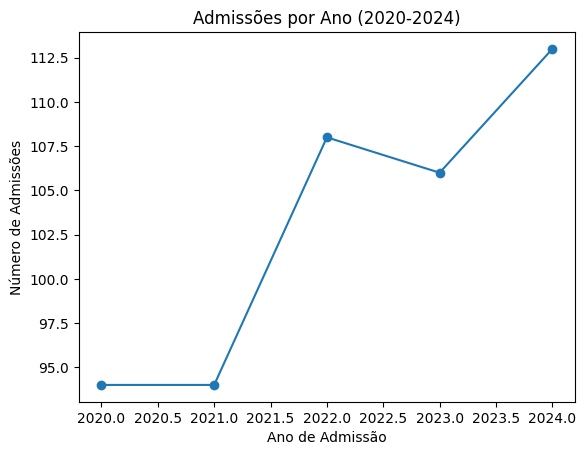

In [6]:
#6. ----------------------------------------------------------------------------------------------------------------------------
#Plotar admissões por ano com `plt.plot(..., marker="o")`:
import matplotlib.pyplot as plt
plt.plot(admissoes_filtradas["Ano_admissao"], admissoes_filtradas["Contagem"], marker="o")
plt.title("Admissões por Ano (2020-2024)")
plt.xlabel("Ano de Admissão")
plt.ylabel("Número de Admissões")
plt.show()

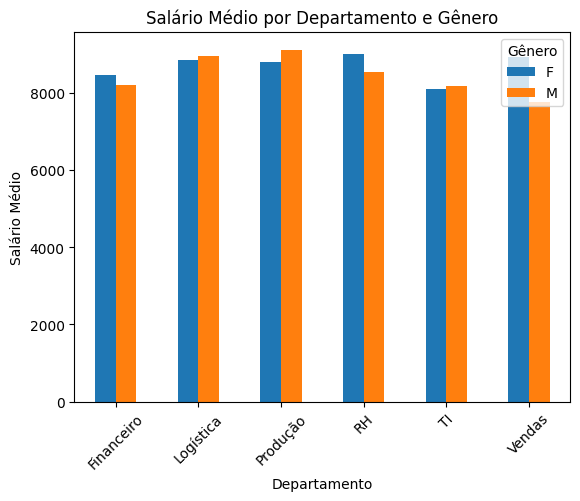

In [7]:
#7. ----------------------------------------------------------------------------------------------------------------------------
#Plotar o `pivot_table` de salário médio por gênero com `pivot.plot(kind="bar")`:
pivot[["F", "M"]].plot(kind="bar")
plt.title("Salário Médio por Departamento e Gênero")
plt.xlabel("Departamento")
plt.ylabel("Salário Médio")
plt.xticks(rotation=45)
plt.legend(title="Gênero")
plt.show()

In [8]:
#8. ----------------------------------------------------------------------------------------------------------------------------
#Fazer a commit com mensagem `feat(alunos): semana 05 - dia 02: groupby, merge, pivot_table, graficos`.  
